# One-click explanations: importance, `explain`, and the `Report`

- Author: [givasile](https://givasile.github.io/)
- Runtime: ~10 s
- Description: A tour of the new high-level API on a known synthetic model:
  per-feature **importance**, the one-click **`effector.explain(...)`** orchestrator, the
  serializable **`Report`** value object (`show` / `plot_importance` / `to_html`), and drilling
  into a heterogeneous feature with **`find_regions` → `Partition`**.

In the earlier tutorials we constructed each effect method by hand, fitted it, and read the
plots one feature at a time. `effector` now offers a high-level layer that automates the whole
triage: **rank features by importance → plot the important ones → automatically split the
*heterogeneous* ones into regions**, all returned as a single serializable `Report`.

In [1]:
import numpy as np
import effector

/home/givasile/github/packages/effector/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## A known black-box model

We use a gated interaction on $D=3$ features, $x_0,x_1\sim\mathcal{U}(-1,1)$ and
$x_2\in\{0,1\}$:

$$ f(x) = \underbrace{\mathbb{1}[x_2=0]}_{\text{gate}} \cdot \operatorname{sign}(x_1)\cdot 3x_0 \; + \; 0.4\,x_1 $$

- $x_0$ has a **strong but heterogeneous** effect: its slope flips with $\operatorname{sign}(x_1)$
  and switches off when $x_2=1$. Globally its mean effect nearly cancels, but it splits cleanly
  into regions.
- $x_1$ has a **weak, homogeneous** effect ($0.4x_1$).
- $x_2$ only gates — no direct additive effect.

This is exactly the situation the report is meant to triage.

In [2]:
rng = np.random.default_rng(0)
N = 3000
x0 = rng.uniform(-1, 1, N)
x1 = rng.uniform(-1, 1, N)
x2 = rng.integers(0, 2, N).astype(float)
X = np.stack([x0, x1, x2], axis=1)

def model(X):
    gate = np.where(X[:, 2] == 0, 1.0, 0.0)
    return gate * np.where(X[:, 1] > 0, 1.0, -1.0) * X[:, 0] * 3.0 + 0.4 * X[:, 1]

def model_jac(X):
    g = np.zeros_like(X)
    gate = np.where(X[:, 2] == 0, 1.0, 0.0)
    g[:, 0] = gate * np.where(X[:, 1] > 0, 1.0, -1.0) * 3.0
    g[:, 1] = 0.4
    return g

# x2 is a binary gate -> declare it nominal so derivative/binning methods treat it as a category
schema = {"feature_names": ["x0", "x1", "x2"],
          "feature_types": ["continuous", "continuous", "nominal"],
          "target_name": "y"}

## 1. Feature importance

`importance(feature, mask=None)` is the **dispersion of the mean effect** of a feature — the
$\mu$-twin of `heter_score` (which measures the spread of the *per-instance* effect). It is
model-free (re-summarised from the cached local effects), centering-invariant, and data-weighted.
`importances()` returns the whole per-feature vector.

In [3]:
pdp = effector.PDP(X, model, schema=schema, nof_instances="all")
pdp.fit("all")

for f, name in enumerate(schema["feature_names"]):
    print(f"{name}:  importance={pdp.importance(f):.3f}   heter_score={pdp.heter_score(f):.3f}")

print("\nimportances() vector:", np.round(pdp.importances(), 3))

x0:  importance=0.021   heter_score=1.622
x1:  importance=0.222   heter_score=1.529
x2:  importance=0.024   heter_score=0.752

importances() vector: [0.021 0.222 0.024]


**Importance and heterogeneity are orthogonal axes.** Note that $x_0$ scores *low* importance
but *high* `heter_score`: because its slope flips with $\operatorname{sign}(x_1)$, the **mean**
effect nearly cancels over the data (low dispersion of the mean = low importance), yet the
**per-instance** effects are wildly spread (high heterogeneity). This is precisely the feature a
global average hides and a **regional** analysis reveals. $x_1$ carries a genuine mean effect;
$x_2$ only gates. `explain` uses both axes: it plots the features with the largest mean effect and
automatically runs `find_regions` on the ones whose heterogeneity is high.

`effector.plot_triage` draws this survey as one picture — the manual counterpart of what `explain` automates. Importance right, heterogeneity up: the top-right corner is where the mean effect hides something.

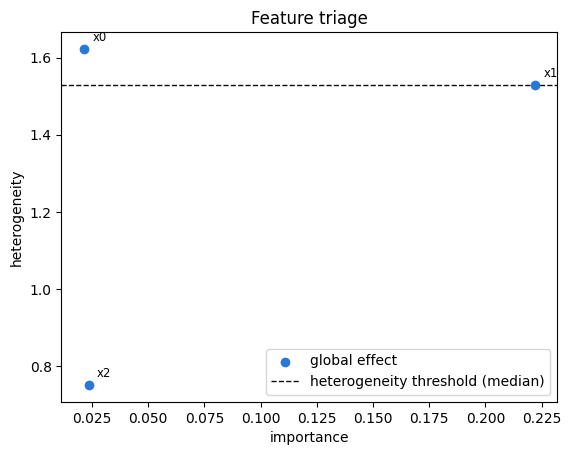

In [4]:
effector.plot_triage(pdp)

## 2. `effector.explain(...)` → `Report`

`explain` runs the entire pipeline in **one model-touch**: fit → rank by importance → build the
top-$k$ curves → `find_regions` on the features whose heterogeneity exceeds a threshold. It
returns a `Report` — a serializable **value** (it owns the computed arrays, not a live reference
to the estimator).

In [5]:
report = effector.explain(X, model, method="pdp", schema=schema,
                          top_k=3, nof_instances="all")
report.show()


PDP report — target: y
feature                   importance     heter  #regions
------------------------------------------------------------
x1                            0.2220    1.5290         7
x2                            0.0236    0.7521         1
x0                            0.0215    1.6223         7


Feature 1 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
x1 🔹 [id: 0 | heter: 1.53 | inst: 3000 | w: 1.00]
    x0 < -0.00 🔹 [id: 1 | heter: 0.95 | inst: 1524 | w: 0.51]
        x2 = 0.00 🔹 [id: 2 | heter: 0.77 | inst: 788 | w: 0.26]
        x2 = 1.00 🔹 [id: 3 | heter: 0.00 | inst: 736 | w: 0.25]
    x0 ≥ -0.00 🔹 [id: 4 | heter: 0.95 | inst: 1476 | w: 0.49]
        x2 = 0.00 🔹 [id: 5 | heter: 0.74 | inst: 732 | w: 0.24]
        x2 = 1.00 🔹 [id: 6 | heter: 0.00 | inst: 744 | w: 0.25]
--------------------------------------------------
Feature 1 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0🔹heter: 1.53
    Level 1🔹heter: 0.95 | 🔻0.58

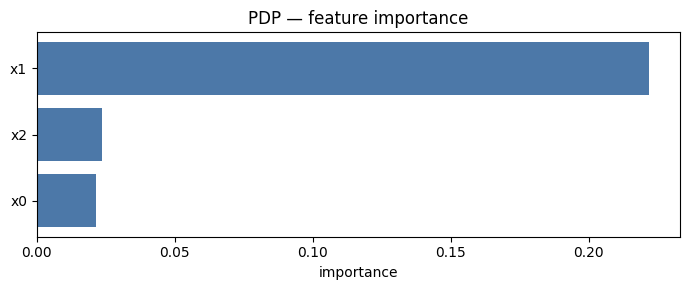

In [6]:
# horizontal importance bar chart (returns (fig, ax) when show_plot=False)
report.plot_importance()

### Self-contained HTML report

`to_html` renders the whole thing to a **single self-contained page** — every figure is inlined
as a base64 PNG, so there are no external assets. This is the artefact you would share with a
stakeholder.

In [7]:
html = report.to_html("explain_report.html")
print("wrote explain_report.html")
print("inlined figures:", "data:image/png;base64" in html)
print("no external assets:", "http://" not in html and "https://" not in html)
print("length (chars):", len(html))

wrote explain_report.html
inlined figures: True
no external assets: True
length (chars): 350374


### The `Report` is a value: it round-trips without the model

`to_dict` / `from_dict` serialise the report; a reloaded report can still render its text and the
importance chart (the live-plot sugar that needs the estimator raises a clear error when unbound).

In [8]:
from effector import Report

reloaded = Report.from_dict(report.to_dict())
print("feature order preserved:", [fr.name for fr in reloaded.features])
reloaded.show()

feature order preserved: ['x1', 'x2', 'x0']

PDP report — target: y
feature                   importance     heter  #regions
------------------------------------------------------------
x1                            0.2220    1.5290         7
x2                            0.0236    0.7521         1
x0                            0.0215    1.6223         7


Feature 1 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
x1 🔹 [id: 0 | heter: 1.53 | inst: 3000 | w: 1.00]
    x0 < -0.00 🔹 [id: 1 | heter: 0.95 | inst: 1524 | w: 0.51]
        x2 = 0.00 🔹 [id: 2 | heter: 0.77 | inst: 788 | w: 0.26]
        x2 = 1.00 🔹 [id: 3 | heter: 0.00 | inst: 736 | w: 0.25]
    x0 ≥ -0.00 🔹 [id: 4 | heter: 0.95 | inst: 1476 | w: 0.49]
        x2 = 0.00 🔹 [id: 5 | heter: 0.74 | inst: 732 | w: 0.24]
        x2 = 1.00 🔹 [id: 6 | heter: 0.00 | inst: 744 | w: 0.25]
--------------------------------------------------
Feature 1 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0

## 3. Drilling into a heterogeneous feature: `find_regions` → `Partition`

The report already ran `find_regions` on the heterogeneous features. We can also call it directly:
it returns a `Partition` (a value object) and stores nothing on the effect. The heterogeneity a
`Partition` reports **is** `heter_score(feature, mask)` on each region's mask.

In [9]:
part = pdp.find_regions(0, finder="best")
part.show()



Feature 0 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
x0 🔹 [id: 0 | heter: 1.62 | inst: 3000 | w: 1.00]
    x1 < 0.00 🔹 [id: 1 | heter: 0.80 | inst: 1480 | w: 0.49]
        x2 = 0.00 🔹 [id: 2 | heter: 0.00 | inst: 742 | w: 0.25]
        x2 = 1.00 🔹 [id: 3 | heter: 0.00 | inst: 738 | w: 0.25]
    x1 ≥ 0.00 🔹 [id: 4 | heter: 0.80 | inst: 1520 | w: 0.51]
        x2 = 0.00 🔹 [id: 5 | heter: 0.00 | inst: 778 | w: 0.26]
        x2 = 1.00 🔹 [id: 6 | heter: 0.00 | inst: 742 | w: 0.25]
--------------------------------------------------
Feature 0 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0🔹heter: 1.62
    Level 1🔹heter: 0.80 | 🔻0.82 (50.66%)
        Level 2🔹heter: 0.00 | 🔻0.80 (100.00%)




In [10]:
# a Partition supports len / iteration / indexing; regions carry mask, heterogeneity, weight, ...
print("number of regions:", len(part))
print("leaves:", [r.idx for r in part.leaves])
for r in part:
    print(f"  region {r.idx}: level={r.level}  inst={r.nof_instances}  heter={r.heterogeneity:.3f}")

number of regions: 7
leaves: [2, 3, 5, 6]
  region 0: level=0  inst=3000  heter=1.622
  region 1: level=1  inst=1480  heter=0.801
  region 2: level=2  inst=742  heter=0.000
  region 3: level=2  inst=738  heter=0.000
  region 4: level=1  inst=1520  heter=0.800
  region 5: level=2  inst=778  heter=0.000
  region 6: level=2  inst=742  heter=0.000


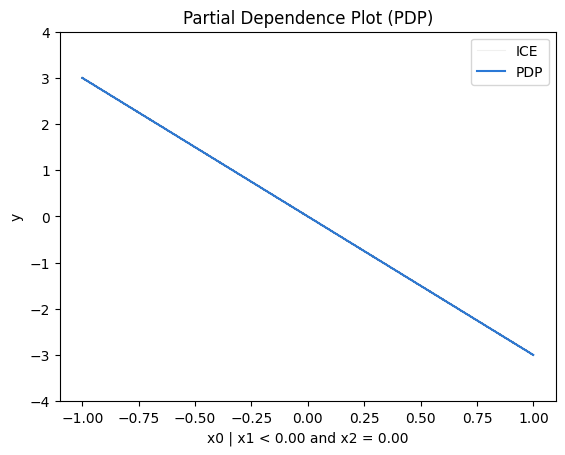

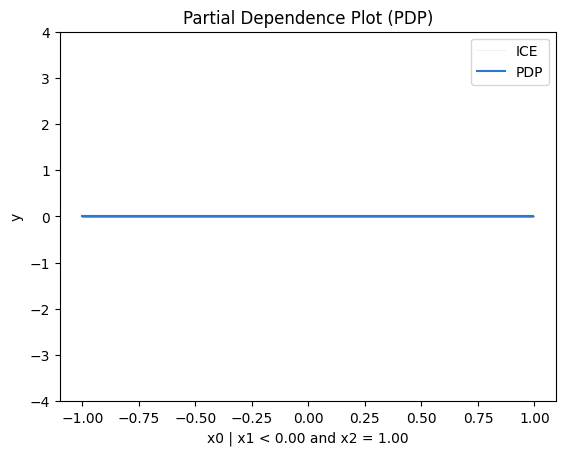

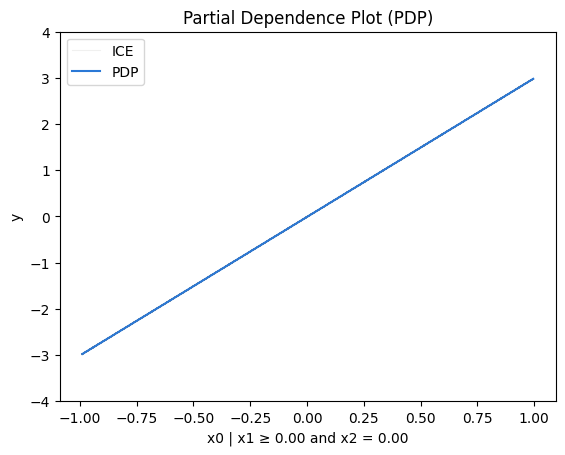

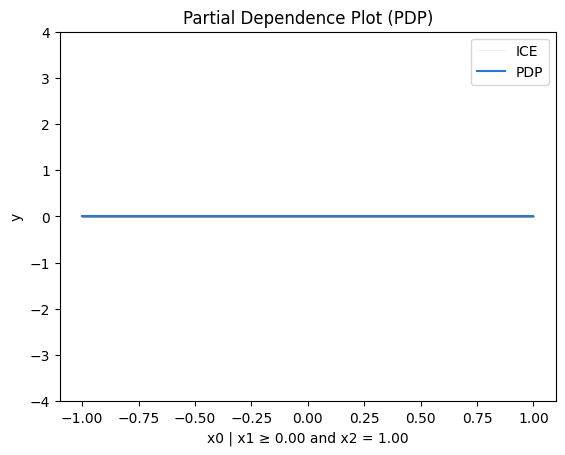

In [11]:
# plot each leaf region: the gated interaction resolves into clean, homogeneous lines
for r in part.leaves:
    part.plot(r.idx, heterogeneity="ice", centering=True, y_limits=[-4, 4])

And the before/after in one figure: arrows from the global point to the leaves — right and down, importance up, heterogeneity explained.

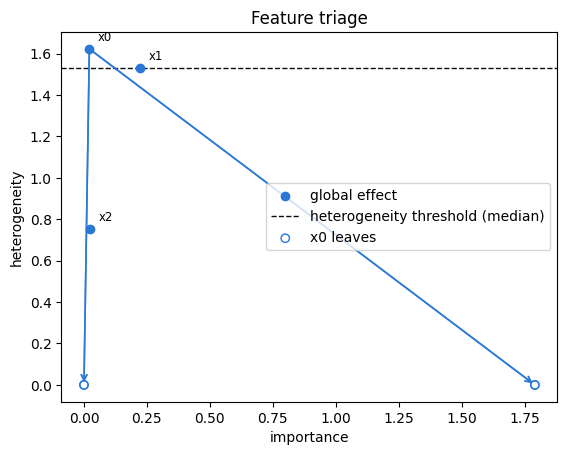

In [12]:
effector.plot_triage(pdp, partitions={"x0": part})

## 4. Same pipeline, any method

`explain` accepts `method="pdp" | "ale" | "rhale" | "shapdp"` (and `"derpdp"`); pass
`model_jac=` for the derivative-based methods. The importance ranking is method-agnostic — the
important feature stays on top.

In [13]:
for method in ["pdp", "ale", "rhale", "shapdp"]:
    kw = {"schema": schema, "top_k": 3, "nof_instances": "all"}
    if method in ("rhale",):
        kw["model_jac"] = model_jac
    if method == "shapdp":
        kw["nof_instances"] = 500  # keep SHAP cheap
    rep = effector.explain(X, model, method=method, **kw)
    ranked = [(fr.name, round(fr.importance, 3)) for fr in rep.features]
    print(f"{method:7s} -> {ranked}")

pdp     -> [('x1', 0.222), ('x2', 0.024), ('x0', 0.021)]
ale     -> [('x1', 0.236), ('x0', 0.056), ('x2', 0.024)]
rhale   -> [('x1', 0.239), ('x0', 0.021)]


/home/givasile/github/packages/effector/effector/report.py:302: UserWarning: importance is undefined for feature(s) ['x2'] — this method does not support their feature type; returned NaN.
  imp = effect.importances()


shapdp  -> [('x1', 0.405), ('x0', 0.376), ('x2', 0.247)]


## Takeaways

- `importance(feature)` / `importances()` give a method-agnostic ranking of feature effect strength.
- `effector.explain(...)` triages a model in one call and returns a serializable `Report`.
- `Report.to_html(path)` produces a single self-contained page to share.
- `find_regions(feature) -> Partition` is the queryable, value-based regional API: `show`, `plot`,
  `eval`, `leaves`, `to_dict` — nothing is stored on the estimator.